In [6]:
from __future__ import annotations
from pathlib import Path
from pathlib import Path
import sys

def find_project_root(marker: str = "README.md") -> Path:
    """Walk up from the current working directory until `marker` is found."""
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root (looked for {marker})")

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from scripts.dataImport import fetch_datasets, load_flow, load_packet
import seaborn as sns
import math

Project root: /Users/mackenziemallett/Desktop/Google Drive/MADS/Professional Foundations+Professional Career Development/Capstone ll/ECE597-Capstone-IoT-IDS


Couldn't figure out how to make projects work so here's the outline we discussed today:

Have a nice weekend - Mack
 
**Goal:** Create a notebook that the group can use to decide what features to keep, and how to treat the features we keep. Have this ready for a team discussion by June 30th at the latest.

Tasks:
 - Reading original paper or watching the attached youtube video to identify features that we don't need (this can be found at the link in the original project pdf from the professor)
 - Notebook draft (see below)

What's in the notebook draft?
 - Improve presentation (more Markdown, change layout)
 - Explain metrics (so far we have a measure of mutual information, distribution comparisons (the violin plots), correlation, statistical comparison (KS statistic and Wasserstein distance), structural profiling, and a time series/frequency view (only for packet data)). We can update this list as needed
 - Draft Interpretation of results (to get the ball rolling when we discuss with the whole team)

In [29]:
fetch_datasets()
results_dir = ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

Datasets already downloaded.


In [8]:

allFlowData = {
    'benign':load_flow("benign"),
    'ddos':load_flow("ddos_http"),
    'dos':load_flow("dos_http"),
    'dns':load_flow("dns_spoofing"),
    'xss':load_flow("xss"),
    'bruteForce':load_flow('brute_force')
}
allPacketData = {
    'benign':load_packet("benign"),
    'ddos':load_packet("ddos_http"),
    'dos':load_packet("dos_http"),
    'dns':load_packet("dns_spoofing"),
    'xss':load_packet("xss"),
    'bruteForce':load_packet('brute_force')
}
print("Done.")


Loading Flow Dataset: benign...
Shape: (398330, 84)
Loading Flow Dataset: ddos_http...
Shape: (505720, 84)
Loading Flow Dataset: dos_http...
Shape: (1642744, 84)
Loading Flow Dataset: dns_spoofing...
Shape: (74856, 84)
Loading Flow Dataset: xss...
Shape: (3377, 84)
Loading Flow Dataset: brute_force...
Shape: (3619, 84)
Loading Packet Dataset: benign...
Shape: (1182798, 135)
Loading Packet Dataset: ddos_http...
Shape: (290346, 135)
Loading Packet Dataset: dos_http...
Shape: (314039, 135)
Loading Packet Dataset: dns_spoofing...
Shape: (296025, 135)
Loading Packet Dataset: xss...
Shape: (40101, 135)
Loading Packet Dataset: brute_force...
Shape: (131477, 135)
Done.


In [9]:
""" Step 1 — Structural profiling.

Replaces the original dataStructure() function. Instead of writing one text
file per dataset, this returns an in-memory dict so downstream steps (time
series, violin, stats, redundancy, MI) can pull the column lists they need
without re-scanning the data or parsing text files.
"""
# from __future__ import annotations


def profile_dataset(df: pd.DataFrame, exclude_cols: list[str], max_unique: int = 15) -> dict:
    """
    Profile a single dataset.

    Parameters
    ----------
    df : the raw dataframe for one dataset (e.g. dataDict["benign"])
    exclude_cols : columns that are numeric-dtype but labels
        (e.g. flowNumericLabels / packetNumericLabels) — excluded from the
        "continuous numeric feature" treatment (no tests),
        but still recorded in the profile in case you need them later
        (e.g. Dst Port for mutual information, per the earlier discussion).
    max_unique : numeric, non-excluded columns with <= this many unique
        (non-NaN, finite) values are flagged is_discrete=True. This feeds
        the discrete_features mask used later for mutual_info_classif
        (flags, Protocol, etc. vs continuous durations/byte counts/rates).
        Computed per-dataset since cardinality is cheap and this profiling
        already iterates every column once; the per-dataset discrete flags
        get unioned across datasets downstream, same as nonzero_var_cols.

    Returns
    -------
    dict with:
        shape: (n_rows, n_cols)
        features: {col_name: {dtype, n_missing, pct_missing, n_inf, is_numeric,
                               is_excluded, mean, var, n_unique, is_discrete}}
        numeric_cols: numeric dtype, NOT in exclude_cols
        nonzero_var_cols: subset of numeric_cols with var > 0 (computed with
            +/-inf excluded -- see note below)
        zero_var_cols: subset of numeric_cols with var == 0 (candidates to drop)
        discrete_cols: subset of numeric_cols with n_unique <= max_unique
        excluded_label_cols: numeric dtype but in exclude_cols (identifiers)
        non_numeric_cols: everything else (object/datetime/etc.)

    Note on inf: rate-style columns (e.g. 'Flow Bytes/s' = bytes / duration). n_inf
    is reported per feature so you can see which columns are affected and
    decide whether to investigate the underlying zero-duration rows
    separately (that condition can itself be informative, e.g. for
    single-packet probe flows).
    """
    n_rows = len(df)
    features = {}
    numeric_cols, nonzero_var_cols, zero_var_cols, discrete_cols = [], [], [], []
    excluded_label_cols, non_numeric_cols = [], []

    for c in df.columns:
        col = df[c]
        n_missing = int(col.isna().sum())
        is_numeric = pd.api.types.is_numeric_dtype(col)
        is_excluded = c in exclude_cols
        n_inf = 0

        entry = {
            "dtype": str(col.dtype),
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / n_rows, 4) if n_rows else 0.0,
            "n_inf": 0,
            "is_numeric": is_numeric,
            "is_excluded": is_excluded,
            "mean": None,
            "var": None,
            "n_unique": None,
            "is_discrete": None,
        }

        if is_numeric:
            if is_excluded:
                excluded_label_cols.append(c)
            else:
                numeric_cols.append(c)
                finite_col = col.replace([np.inf, -np.inf], np.nan)
                n_inf = int(np.isinf(col).sum())
                entry["n_inf"] = n_inf
                var = float(finite_col.var())
                mean = float(finite_col.mean())
                entry["mean"] = mean
                entry["var"] = var
                if var and var > 0 and not pd.isna(var):
                    nonzero_var_cols.append(c)
                else:
                    zero_var_cols.append(c)

                n_unique = int(finite_col.nunique(dropna=True))
                is_discrete = n_unique <= max_unique
                entry["n_unique"] = n_unique
                entry["is_discrete"] = is_discrete
                if is_discrete:
                    discrete_cols.append(c)
        else:
            non_numeric_cols.append(c)

        features[c] = entry

    return {
        "shape": df.shape,
        "features": features,
        "numeric_cols": numeric_cols,
        "nonzero_var_cols": nonzero_var_cols,
        "zero_var_cols": zero_var_cols,
        "discrete_cols": discrete_cols,
        "excluded_label_cols": excluded_label_cols,
        "non_numeric_cols": non_numeric_cols,
    }

def profile_all(dataDict: dict[str, pd.DataFrame], exclude_cols: list[str], max_unique: int = 15) -> dict:
    """Run profile_dataset across every dataset in dataDict. Returns {name: profile_dict}."""
    out = {}
    for name, df in dataDict.items():
        out[name] = profile_dataset(df, exclude_cols, max_unique=max_unique)
        # missing_feats = [
        #     c for c, info in out[name]["features"].items() if info["n_missing"] > 0
        # ]
        # if missing_feats:
        #     print(f"[{name}] {len(missing_feats)} feature(s) have missing values: {missing_feats}")
        inf_feats = {
            c: info["n_inf"] for c, info in out[name]["features"].items() if info["n_inf"] > 0
        }
        if inf_feats:
            print(f"[{name}] {len(inf_feats)} feature(s) have +/-inf values (mean/var computed "
                  f"excluding inf): {inf_feats}")
        # n_zero = len(out[name]["zero_var_cols"])
        # if n_zero:
        #     print(f"[{name}] {n_zero} numeric feature(s) have zero variance: {out[name]['zero_var_cols']}")
    return out

def feature_profile_comparison(profile: dict) -> pd.DataFrame:
    """
    Returns
    -------
    pd.DataFrame
        MultiIndex DataFrame: (col_name, dataset) as rows,
        feature keys as columns.
    """
    records = []

    for dataset_name, df_info in profile.items():
        features = df_info.get("features", {})

        # Precompute membership sets for fast lookup
        numeric_cols       = set(df_info.get("numeric_cols", []))
        nonzero_var_cols   = set(df_info.get("nonzero_var_cols", []))
        zero_var_cols      = set(df_info.get("zero_var_cols", []))
        discrete_cols      = set(df_info.get("discrete_cols", []))
        excluded_label_cols = set(df_info.get("excluded_label_cols", []))
        non_numeric_cols   = set(df_info.get("non_numeric_cols", []))

        for col_name, col_stats in features.items():
            record = {
                "col_name":   col_name,
                "dataset":    dataset_name,
                # ── per-feature stats ──────────────────────────────────────
                **col_stats,
                # ── dataset-level membership flags ─────────────────────────
                "in_numeric_cols":        col_name in numeric_cols,
                "in_nonzero_var_cols":    col_name in nonzero_var_cols,
                "in_zero_var_cols":       col_name in zero_var_cols,
                "in_discrete_cols":       col_name in discrete_cols,
                "in_excluded_label_cols": col_name in excluded_label_cols,
                "in_non_numeric_cols":    col_name in non_numeric_cols,
            }
            records.append(record)

    df = pd.DataFrame(records)

    if df.empty:
        return df

    # Group by col_name first, then dataset — so each feature's rows are together
    df = (
        df
        .set_index(["col_name", "dataset"])
        .sort_index(level=["col_name", "dataset"])
    )

    return df

In [10]:
""" Step 4 — Wasserstein (all pairwise combinations of datasets, per
feature).

Outputs a long-format DataFrame: one row per (feature, dataset_a, dataset_b)
with the Wasserstein distance. 
"""
# from __future__ import annotations
def compare_pair(s_a: pd.Series, s_b: pd.Series) -> dict:
    """
    Note: +/-inf values (e.g. from 'Flow Bytes/s' when Flow Duration == 0)
    are dropped here the same as NaN. Left in, wasserstein_distance silently
    returns inf, which would dominate any ranking built on top of this
    (see top_separating_features).
    """
    a = pd.Series(s_a).replace([np.inf, -np.inf], np.nan).dropna().values
    b = pd.Series(s_b).replace([np.inf, -np.inf], np.nan).dropna().values
    if len(a) == 0 or len(b) == 0:
        return {"wasserstein": None, "n_a": len(a), "n_b": len(b)}
    wd = wasserstein_distance(a, b)
    return {"wasserstein": wd, "n_a": len(a), "n_b": len(b)}


def run_statistical_comparison(
    dataDict: dict[str, pd.DataFrame],
    features: list[str],
) -> pd.DataFrame:
    """
    All-pairwise statistical comparison across datasets for each feature.

    Returns a long DataFrame:
        feature, dataset_a, dataset_b, wasserstein, n_a, n_b
    """
    rows = []
    dataset_names = list(dataDict.keys())

    for feature in features:
        for name_a, name_b in combinations(dataset_names, 2):
            df_a, df_b = dataDict[name_a], dataDict[name_b]
            if feature not in df_a.columns or feature not in df_b.columns:
                continue
            result = compare_pair(df_a[feature], df_b[feature])
            rows.append({
                "feature": feature,
                "dataset_a": name_a,
                "dataset_b": name_b,
                **result,
            })

    return pd.DataFrame(rows)

def sample_to_deployment_mix(
    dataDict: dict[str, pd.DataFrame],
    total_n: int = 200_000,
    benign_frac: float = 0.97,
    benign_key: str = "benign",
    random_state: int = 0,
) -> dict[str, pd.DataFrame]:
    """
    Resample dataDict to match the class mix the final build will actually
    draw at inference/training time: benign_frac of total_n from benign,
    the remainder split across attack classes proportional to their
    natural relative sizes in dataDict (so dos, with far more raw rows
    than xss, gets a proportionally larger slice of the attack budget --
    mirroring a uniform-random draw from the full attack pool). This is
    the single source of truth for any deployment-weighted metric
    (pooled Wasserstein, weighted pairwise Wasserstein, MI pooling, etc.)
    so they all answer the same weighted question.

    If a class's proportional target exceeds its available rows (e.g. a
    tiny class like xss/bruteForce under an unlucky split), it's capped at
    the available row count and a warning is printed -- sampling with
    replacement would invent duplicate rows that don't exist in
    deployment, which would be worse for this kind of analysis.
    """
    benign_n = int(round(total_n * benign_frac))
    attack_budget = total_n - benign_n

    attack_names = [k for k in dataDict if k != benign_key]
    attack_sizes = {k: len(dataDict[k]) for k in attack_names}
    total_attack_rows = sum(attack_sizes.values())

    out = {}
    benign_df = dataDict[benign_key]
    benign_take = min(benign_n, len(benign_df))
    if benign_take < benign_n:
        print(f"[sample_to_deployment_mix] benign only has {len(benign_df)} rows, "
              f"wanted {benign_n} -- using all available")
    out[benign_key] = benign_df.sample(n=benign_take, random_state=random_state)

    for name in attack_names:
        share = attack_sizes[name] / total_attack_rows if total_attack_rows else 0
        target = int(round(attack_budget * share))
        take = min(target, attack_sizes[name])
        if take < target:
            print(f"[sample_to_deployment_mix] {name} only has {attack_sizes[name]} rows, "
                  f"wanted {target} -- using all available")
        out[name] = (
            dataDict[name].sample(n=take, random_state=random_state)
            if take > 0 else dataDict[name].iloc[0:0]
        )

    actual_total = sum(len(v) for v in out.values())
    actual_benign_pct = round(100 * len(out[benign_key]) / actual_total, 2) if actual_total else 0.0
    print(f"[sample_to_deployment_mix] sampled {actual_total} rows total "
          f"({actual_benign_pct}% benign, target was {benign_frac * 100}%)")

    return out


def sample_attack_only_mix(
    dataDict: dict[str, pd.DataFrame],
    total_n: int = 200_000,
    benign_key: str = "benign",
    random_state: int = 0,
) -> dict[str, pd.DataFrame]:
    """
    Resample to attack classes ONLY -- no benign at all -- proportional to
    each attack class's natural relative size within the attack
    population. Use this for the classification pipeline: in a two-stage
    architecture (anomaly detector flags traffic, THEN the classifier
    labels the attack type), the classifier never sees the full 97/3
    benign/attack mix -- it only ever runs on traffic already filtered to
    attack. sample_to_deployment_mix's 97/3 split is the right mix for the
    anomaly/binary stage; this is the right mix for the classification stage.
    """
    attack_names = [k for k in dataDict if k != benign_key]
    attack_sizes = {k: len(dataDict[k]) for k in attack_names}
    total_attack_rows = sum(attack_sizes.values())

    out = {}
    for name in attack_names:
        share = attack_sizes[name] / total_attack_rows if total_attack_rows else 0
        target = int(round(total_n * share))
        take = min(target, attack_sizes[name])
        if take < target:
            print(f"[sample_attack_only_mix] {name} only has {attack_sizes[name]} rows, "
                  f"wanted {target} -- using all available")
        out[name] = (
            dataDict[name].sample(n=take, random_state=random_state)
            if take > 0 else dataDict[name].iloc[0:0]
        )

    actual_total = sum(len(v) for v in out.values())
    print(f"[sample_attack_only_mix] sampled {actual_total} attack rows total "
          f"across {len(out)} class(es) (no benign)")
    return out


def pooled_wasserstein_vs_benign(
    dataDict: dict[str, pd.DataFrame],
    features: list[str],
    benign_key: str = "benign",
) -> pd.DataFrame:
    """
    Wasserstein distance per feature between benign and ALL attack rows
    pooled into one distribution. Call this on a dataDict that's already
    been resampled to deployment proportions (sample_to_deployment_mix) --
    pooling means each class's row count directly drives its influence on
    the result, so on raw per-class data a dominant class (dos at 1.6M
    rows) would swamp the comparison in a way that doesn't match what the
    final model actually sees at a 97/3 benign/attack mix.

    Also reports normalized_wasserstein (raw distance / pooled std across
    the same deployment-weighted sample) so features on very different
    scales (Flow Duration in microseconds vs a 0-1 ratio) are comparable.
    """
    benign_df = dataDict[benign_key]
    attack_df = pd.concat(
        [df for name, df in dataDict.items() if name != benign_key],
        ignore_index=True,
    )

    rows = []
    for feature in features:
        if feature not in benign_df.columns or feature not in attack_df.columns:
            continue
        result = compare_pair(benign_df[feature], attack_df[feature])
        if result["wasserstein"] is None:
            continue

        pooled = pd.concat([benign_df[feature], attack_df[feature]])
        pooled = pooled.replace([np.inf, -np.inf], np.nan).dropna()
        std = pooled.std()
        if not std or std == 0 or pd.isna(std):
            continue

        rows.append({
            "feature": feature,
            "wasserstein": result["wasserstein"],
            "pooled_std": std,
            "normalized_wasserstein": result["wasserstein"] / std,
            "n_benign": result["n_a"],
            "n_attack": result["n_b"],
        })

    out = pd.DataFrame(rows).sort_values("normalized_wasserstein", ascending=False)
    return out.reset_index(drop=True)


def top_separating_features_weighted(
    dataDict: dict[str, pd.DataFrame],
    stats_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Mean Wasserstein distance per feature across dataset-pairs, weighted by
    pair sample size (min(n_a, n_b)) instead of an unweighted mean across
    pairs. Call this on a stats_df built from a deployment-weighted
    dataDict (sample_to_deployment_mix) so both the underlying row counts
    AND the pair weighting reflect the class mix the final build will
    actually train/run on -- otherwise a tiny class like xss/bruteForce
    counts exactly as much as dos/ddos in the average.
    """
    rows = []
    for feature, group in stats_df.groupby("feature"):
        all_vals = pd.concat([df[feature] for df in dataDict.values() if feature in df.columns])
        all_vals = all_vals.replace([np.inf, -np.inf], np.nan).dropna()
        std = all_vals.std()
        if not std or std == 0 or pd.isna(std):
            continue

        weights = group[["n_a", "n_b"]].min(axis=1)
        if weights.sum() == 0:
            continue
        weighted_wd = np.average(group["wasserstein"], weights=weights)

        rows.append({
            "feature": feature,
            "wasserstein": weighted_wd,
            "pooled_std": std,
            "normalized_wasserstein": weighted_wd / std,
        })

    out = pd.DataFrame(rows).sort_values("normalized_wasserstein", ascending=False)
    return out.reset_index(drop=True)


In [11]:
""" Step 6 — Feature ranking via mutual information.

Builds a combined (benign + all attack) frame with a label column, then
computes mutual information between each feature and the label. This is the
main "which features actually separate benign from attack" payoff step,
independent of any model's distributional assumptions.

Two label modes:
  - binary: benign vs attack (everything non-benign collapsed to 1 label)
  - multiclass: benign vs ddos vs dos vs dns vs xss vs bruteForce, etc.
Both are useful for different questions (binary = pure IDS, multiclass =
attack-type classification), so this computes both by default.
"""
from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif


def build_labeled_frame(
    dataDict: dict[str, pd.DataFrame],
    features: list[str],
    benign_key: str = "benign",
    sample_n: int | None = 100_000,
    random_state: int = 0,
) -> pd.DataFrame:
    """
    Stack all datasets into one frame with a 'label_binary' (benign/attack)
    and 'label_multiclass' (dataset name) column, restricted to `features`.
    Samples each dataset down to sample_n rows if larger, to keep the MI
    computation tractable at your scale (dos alone is 1.6M flow rows).
    """
    frames = []
    for name, df in dataDict.items():
        valid_cols = [c for c in features if c in df.columns]
        sub = df[valid_cols].copy()
        if sample_n is not None and len(sub) > sample_n:
            sub = sub.sample(n=sample_n, random_state=random_state)
        sub["label_multiclass"] = name
        sub["label_binary"] = "benign" if name == benign_key else "attack"
        frames.append(sub)
    return pd.concat(frames, ignore_index=True)


def compute_mutual_information(
    labeled_df: pd.DataFrame,
    features: list[str],
    label_col: str = "label_binary",
    random_state: int = 0,
    discrete_features: set[str] | None = None,
) -> pd.DataFrame:
    """
    Mutual information between each feature and label_col, computed
    PER-FEATURE independently rather than over one joint matrix.

    Why per-feature: protocol-specific columns (e.g. http_response_code,
    dns_query_type, icmp_type) are NaN by design for any packet that isn't
    that protocol. A joint dropna() across all features requires a single
    row to be non-null in every feature simultaneously -- which for
    mutually-exclusive protocol fields is nearly impossible, and was
    dropping ~99.7% of rows on the packet/anomaly pipeline. Computing MI
    one feature at a time means each feature only loses the rows where
    THAT feature is inf/NaN, not rows where some unrelated feature happens
    to be inf/NaN.

    Cost: N single-column mutual_info_classif calls instead of 1 call over
    the full matrix. Slower, but correctness here matters more than speed,
    and N is at most ~120.

    discrete_features : names of columns (from profile_dataset's discrete_cols,
        unioned across datasets) to mark discrete for mutual_info_classif.
        Anything not in this set is treated as continuous. If None, falls
        back to sklearn's 'auto' heuristic per feature.

    Returns a DataFrame sorted descending by MI score, plus n_rows_used so
    you can see how much data backed each feature's score (features that
    are protocol-specific will legitimately have far fewer rows than
    universal ones -- that's expected, not a bug).
    """
    valid_cols = [c for c in features if c in labeled_df.columns]
    y_full = labeled_df[label_col]

    rows = []
    for feature in valid_cols:
        col = labeled_df[feature]

        if pd.api.types.is_numeric_dtype(col):
            col = col.replace([np.inf, -np.inf], np.nan)

        mask = col.notna()
        n_before = len(col)
        n_after = int(mask.sum())
        n_dropped = n_before - n_after

        if n_after == 0:
            rows.append({"feature": feature, "mutual_info": np.nan, "n_rows_used": 0})
            continue

        X = col[mask].to_frame()
        y = y_full[mask]

        is_discrete = (
            [feature in discrete_features] if discrete_features is not None else "auto"
        )

        mi = mutual_info_classif(X, y, discrete_features=is_discrete, random_state=random_state)[0]
        rows.append({"feature": feature, "mutual_info": mi, "n_rows_used": n_after})

        if n_dropped > 0:
            pct = round(100 * n_dropped / n_before, 2) if n_before else 0.0
            print(f"[mutual_info:{label_col}] {feature}: dropped {n_dropped}/{n_before} "
                  f"rows ({pct}%) due to inf/NaN")

    return (
        pd.DataFrame(rows)
        .sort_values("mutual_info", ascending=False)
        .reset_index(drop=True)
    )


def run_mutual_information_step(
    dataDict: dict[str, pd.DataFrame],
    features: list[str],
    benign_key: str = "benign",
    sample_n: int | None = 100_000,
    discrete_features: set[str] | None = None,
) -> dict[str, pd.DataFrame]:
    """
    Convenience wrapper: builds the labeled frame once, computes both binary
    and multiclass MI rankings. Returns {"binary": df, "multiclass": df}.
    """
    labeled = build_labeled_frame(dataDict, features, benign_key=benign_key, sample_n=sample_n)
    return {
        "binary": compute_mutual_information(labeled, features, label_col="label_binary",
                                              discrete_features=discrete_features),
        "multiclass": compute_mutual_information(labeled, features, label_col="label_multiclass",
                                                  discrete_features=discrete_features),
    }


In [12]:
""" Pipeline drivers."""
# from __future__ import annotations
def _common_nonzero_var_features(profiles: dict) -> list[str]:
    """
    Union vs intersection matters here: a feature with zero variance in ONE
    dataset (e.g. a flag that's always 0 in benign traffic but varies under
    attack) is exactly the kind of feature you want to catch, not discard.
    So we take the UNION of nonzero_var_cols across datasets, not the
    intersection — a feature is included if it has signal in at least one
    dataset.
    """
    all_cols = set()
    for p in profiles.values():
        all_cols.update(p["nonzero_var_cols"])
    return sorted(all_cols)


def _common_discrete_features(profiles: dict) -> set[str]:
    """
    Union of discrete_cols across datasets, same reasoning as
    _common_nonzero_var_features: a flag-like column is still flag-like
    even if one dataset happens to only show one of its values (e.g. a
    flag that's always 0 in benign traffic). Returned as a set for fast
    membership checks when building the discrete_features mask passed to
    mutual_info_classif.
    """
    discrete = set()
    for p in profiles.values():
        discrete.update(p["discrete_cols"])
    return discrete


def run_packet_pipeline(
    dataDict: dict[str, pd.DataFrame],
    exclude_cols: list[str],
    benign_key: str = "benign",
    save_root: Path | None = None,
    deployment_total_n: int = 200_000,
    deployment_benign_frac: float = 0.97,
) -> dict:
    """This is set up to identify the features we should use to identify features for
    anomoly detection"""
    results = {}

    print("=== Step 1: structural profiling ===")
    profiles = profile_all(dataDict, exclude_cols)
    results["profiles"] = profiles
    nonzero_var_by_dataset = {name: p["nonzero_var_cols"] for name, p in profiles.items()}
    features = _common_nonzero_var_features(profiles)
    results["features_used"] = features
    discrete_features = _common_discrete_features(profiles) & set(features)
    results["discrete_features"] = discrete_features
    #Wasserstein Distance -- benign vs all-attack pooled, on a deployment-weighted sample
    print("=== Step 4: pooled statistical comparison (benign vs all-attack, deployment-weighted) ===")
    deployment_sample = sample_to_deployment_mix(
        dataDict, total_n=deployment_total_n, benign_frac=deployment_benign_frac, benign_key=benign_key
    )
    results["deployment_sample"] = deployment_sample
    results["Wasserstein"] = pooled_wasserstein_vs_benign(deployment_sample, features, benign_key=benign_key)
    #Mutual Information -- computed on the SAME deployment-weighted sample as Wasserstein,
    # so both metrics are answering the same 97/3 benign/attack question. sample_n=None
    # because deployment_sample is already capped to deployment_total_n -- letting
    # run_mutual_information_step's own cap re-truncate it would silently distort the mix
    # (e.g. clipping benign back down to 100k and breaking the intended 97% share).
    print("=== Step 6: mutual information ranking (deployment-weighted) ===")
    results["mutual_info"] = run_mutual_information_step(
        deployment_sample, features, benign_key=benign_key,
        discrete_features=discrete_features, sample_n=None
    )

    return results


def run_flow_pipeline(
    dataDict: dict[str, pd.DataFrame],
    exclude_cols: list[str],
    benign_key: str = "benign",
    save_root: Path | None = None,
    deployment_total_n: int = 200_000,
) -> dict:
    """This is setup to identify the features we should use for classification 
    among attack datasets"""
    results = {}

    print("=== Step 1: structural profiling ===")
    profiles = profile_all(dataDict, exclude_cols)
    results["profiles"] = profiles
    nonzero_var_by_dataset = {name: p["nonzero_var_cols"] for name, p in profiles.items()}
    features = _common_nonzero_var_features(profiles)
    results["features_used"] = features
    discrete_features = _common_discrete_features(profiles) & set(features)
    results["discrete_features"] = discrete_features
    print(f"{len(features)} feature(s) with nonzero variance in at least one dataset")
    #Wasserstein -- attack-vs-attack pairwise, weighted by pair size, on an
    # ATTACK-ONLY sample (no benign): the classifier only ever runs on
    # traffic already flagged as attack by the upstream anomaly detector,
    # so benign's relative size never enters this stage's question.
    print("=== Step 4: statistical comparison (attack-vs-attack, attack-only sample) ===")
    deployment_sample = sample_attack_only_mix(
        dataDict, total_n=deployment_total_n, benign_key=benign_key
    )
    results["deployment_sample"] = deployment_sample
    stats_df = run_statistical_comparison(deployment_sample, features)
    results["stats"] = stats_df
    results["Wasserstein"] = top_separating_features_weighted(deployment_sample, stats_df)

    #mutual information -- multiclass ONLY, on the same attack-only sample.
    # label_binary is skipped here on purpose: with no benign present, every
    # row would carry the same 'attack' label, which is a degenerate target
    # (zero variance) and not a question this pipeline is meant to answer --
    # that's the anomaly/packet pipeline's job, not the classifier's.
    print("=== Step 6: mutual information ranking (multiclass, attack-only sample) ===")
    labeled = build_labeled_frame(deployment_sample, features, benign_key=benign_key, sample_n=None)
    results["mutual_info"] = {
        "multiclass": compute_mutual_information(
            labeled, features, label_col="label_multiclass", discrete_features=discrete_features
        )
    }

    return results

Number of available features. Best practice indicates that we want roughly 100^d data points per feature. 206_200 rows available

In [13]:
def plt_data_needed_classic(data, rows_per_feature: float=100.0, data_available = 206_200):
    """Based on the classic 100^dimensions rule"""
    n = len(data.columns)
    features = np.arange(1, n + 1)
    
    data_needed = rows_per_feature ** features 
    exact_intercept = math.log10(data_available) / math.log10(rows_per_feature)
    intercept_int = math.floor(exact_intercept)
    plt.plot(features, data_needed, label='Data Needed')
    plt.axhline(data_available, color='r', label='Data Available')
    plt.yscale('log')
    plt.legend()
    plt.show()
    return intercept_int

def plt_data_needed_simple(data, rows_per_feature: float=50.0, data_available = 206_200):
    """For algorithms like Random Forests, SVMs, or Logistic Regression"""
    n = len(data.columns)
    features = np.arange(1, n + 1)
    
    data_needed = rows_per_feature * features 
    exact_intercept = data_available / rows_per_feature
    intercept_int = math.floor(exact_intercept)
    plt.plot(features, data_needed, label='Data Needed')
    plt.axhline(data_available, color='r', label='Data Available')
    # plt.yscale('log')
    plt.legend()
    plt.show()
    return intercept_int

def plt_data_needed_nn(data, rows_per_feature: float=50.0, data_available = 206_200):
    """For deep neural networks like Convolutional Neural Netowrks (auto-encoder), Transformers, or Reccurent-Neural Networks"""
    n = len(data.columns)
    features = np.arange(1, n + 1)
    
    data_needed = rows_per_feature * features 
    exact_intercept = data_available / rows_per_feature
    intercept_int = math.floor(exact_intercept)
    plt.plot(features, data_needed, label='Data Needed')
    plt.axhline(data_available, color='r', label='Data Available')
    # plt.yscale('log')
    plt.legend()
    plt.show()
    return intercept_int

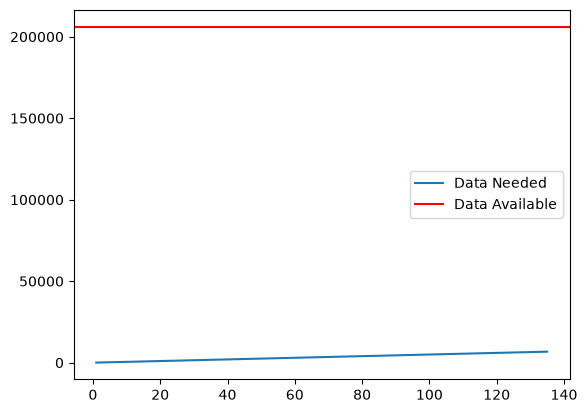

Freatures allowed: 4124


In [14]:
flow_features_allowed = plt_data_needed_simple(allPacketData['benign'])
print(f"Freatures allowed: {flow_features_allowed}")

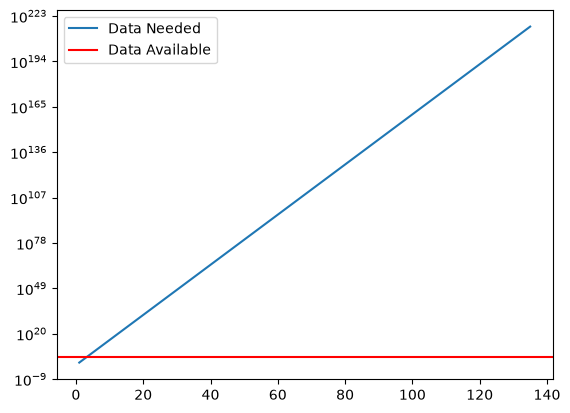

Freatures allowed: 3


In [15]:
packet_features_allowed = plt_data_needed_classic(allPacketData['benign'], 40.0)
print(f"Freatures allowed: {packet_features_allowed}")

according to gemini we want about 10-20 of the best features

## General Pipeline Steps
I've removed columns used for labeling and timestamps, since these will probably be nesessary anyway. 

I've only done the following tests on columns with more than 0 variance. Two good reasons for this:
 - Correlation involves dividing by the variance. If there's a 0 variance, this would mean dividing by 0, creating an inf value $r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}$
 - The Wasserstein distance of two identical constant distributions is 0, which would be indistinguishable from a genuinly non-seperating feature. So Wasserstein distance is not computed on columns which have a non-zero variance on at least one column
 - Mutual Information behaves unpredictable on constants
 

## Analysis for Anomoly Detection
exclude_cols is used for labling and timestamp cols, since we'll likely need to include them regardless

In [16]:
#These are the Unique ID's for packet data
packetNumericLables = ['src_ip', 'dst_ip', 'src_port', 'dst_port']

In [17]:
ano_results = run_packet_pipeline(dataDict=allPacketData, exclude_cols=packetNumericLables)

=== Step 1: structural profiling ===
=== Step 4: pooled statistical comparison (benign vs all-attack, deployment-weighted) ===
[sample_to_deployment_mix] sampled 200000 rows total (97.0% benign, target was 97.0%)
=== Step 6: mutual information ranking (deployment-weighted) ===
[mutual_info:label_binary] channel_10_var: dropped 8904/200000 rows (4.45%) due to inf/NaN
[mutual_info:label_binary] channel_1_var: dropped 25808/200000 rows (12.9%) due to inf/NaN
[mutual_info:label_binary] channel_30_var: dropped 3584/200000 rows (1.79%) due to inf/NaN
[mutual_info:label_binary] channel_5_var: dropped 17725/200000 rows (8.86%) due to inf/NaN
[mutual_info:label_binary] channel_60_var: dropped 1945/200000 rows (0.97%) due to inf/NaN
[mutual_info:label_binary] dns_query_type: dropped 190705/200000 rows (95.35%) due to inf/NaN
[mutual_info:label_binary] jitter: dropped 5280/200000 rows (2.64%) due to inf/NaN
[mutual_info:label_binary] src_ip_10_count: dropped 8756/200000 rows (4.38%) due to inf/Na

#### Below are the columns which contain zero-variance

In [18]:
anofpc = feature_profile_comparison(ano_results['profiles'])
anofpc.loc[anofpc['in_zero_var_cols']==True]

dtype  n_missing  pct_missing  n_inf  \
col_name               dataset                                            
handshake_ciphersuites benign      int64          0          0.0      0   
                       bruteForce  int64          0          0.0      0   
                       ddos        int64          0          0.0      0   
                       dns         int64          0          0.0      0   
                       dos         int64          0          0.0      0   
                       xss         int64          0          0.0      0   

                                   is_numeric  is_excluded  mean  var  \
col_name               dataset                                          
handshake_ciphersuites benign            True        False  -1.0  0.0   
                       bruteForce        True        False  -1.0  0.0   
                       ddos              True        False  -1.0  0.0   
                       dns               True        False  -1.0  0.0   
                       dos               True        False  -1.0  0.0   
                       xss               True        False  -1.0  0.0   

                                   n_unique is_discrete  in_numeric_cols  \
col_name               dataset                                             
handshake_ciphersuites benign           1.0        True             True   
                       bruteForce       1.0        True             True   
                       ddos             1.0        True             True   
                       dns              1.0        True             True   
                       dos              1.0        True             True   
                       xss              1.0        True             True   

                                   in_nonzero_var_cols  in_zero_var_cols  \
col_name               dataset                                             
handshake_ciphersuites benign                    False              True   
                       bruteForce                False              True   
                       ddos                      False              True   
                       dns                       False              True   
                       dos                       False              True   
                       xss                       False              True   

                                   in_discrete_cols  in_excluded_label_cols  \
col_name               dataset                                                
handshake_ciphersuites benign                  True                   False   
                       bruteForce              True                   False   
                       ddos                    True                   False   
                       dns                     True                   False   
                       dos                     True                   False   
                       xss                     True                   False   

                                   in_non_numeric_cols  
col_name               dataset                          
handshake_ciphersuites benign                    False  
                       bruteForce                False  
                       ddos                      False  
                       dns                       False  
                       dos                       False  
                       xss                       False

### Wasserstien Distance
what i'm interested in is the attack features distance from the benign dataset. So, I've filtered to only give results relative to the benign dataset. Looking to remove low Wasserstein values

In [19]:
wassThresh1 = 1.0
mutThress = 0.035
wassData = ano_results['Wasserstein']

In [20]:
anofpc.loc[anofpc['in_numeric_cols']==False]

dtype  n_missing  pct_missing  n_inf  is_numeric  \
col_name   dataset                                                       
device_mac benign       str          0          0.0      0       False   
           bruteForce   str          0          0.0      0       False   
           ddos         str          0          0.0      0       False   
           dns          str          0          0.0      0       False   
           dos          str          0          0.0      0       False   
...                     ...        ...          ...    ...         ...   
user_agent bruteForce   str          0          0.0      0       False   
           ddos         str          0          0.0      0       False   
           dns          str          0          0.0      0       False   
           dos          str          0          0.0      0       False   
           xss          str          0          0.0      0       False   

                       is_excluded  mean  var  n_unique is_discrete  \
col_name   dataset                                                    
device_mac benign            False   NaN  NaN       NaN        None   
           bruteForce        False   NaN  NaN       NaN        None   
           ddos              False   NaN  NaN       NaN        None   
           dns               False   NaN  NaN       NaN        None   
           dos               False   NaN  NaN       NaN        None   
...                            ...   ...  ...       ...         ...   
user_agent bruteForce        False   NaN  NaN       NaN        None   
           ddos              False   NaN  NaN       NaN        None   
           dns               False   NaN  NaN       NaN        None   
           dos               False   NaN  NaN       NaN        None   
           xss               False   NaN  NaN       NaN        None   

                       in_numeric_cols  in_nonzero_var_cols  in_zero_var_cols  \
col_name   dataset                                                              
device_mac benign                False                False             False   
           bruteForce            False                False             False   
           ddos                  False                False             False   
           dns                   False                False             False   
           dos                   False                False             False   
...                                ...                  ...               ...   
user_agent bruteForce            False                False             False   
           ddos                  False                False             False   
           dns                   False                False             False   
           dos                   False                False             False   
           xss                   False                False             False   

                       in_discrete_cols  in_excluded_label_cols  \
col_name   dataset                                                
device_mac benign                 False                   False   
           bruteForce             False                   False   
           ddos                   False                   False   
           dns                    False                   False   
           dos                    False                   False   
...                                 ...                     ...   
user_agent bruteForce             False                   False   
           ddos                   False                   False   
           dns                    False                   False   
           dos                    False                   False   
           xss                    False                   False   

                       in_non_numeric_cols  
col_name   dataset                          
device_mac benign                     True  
           bruteForce                 True  
           ddos              

In [21]:
mutual_info_df = ano_results['mutual_info']['binary']

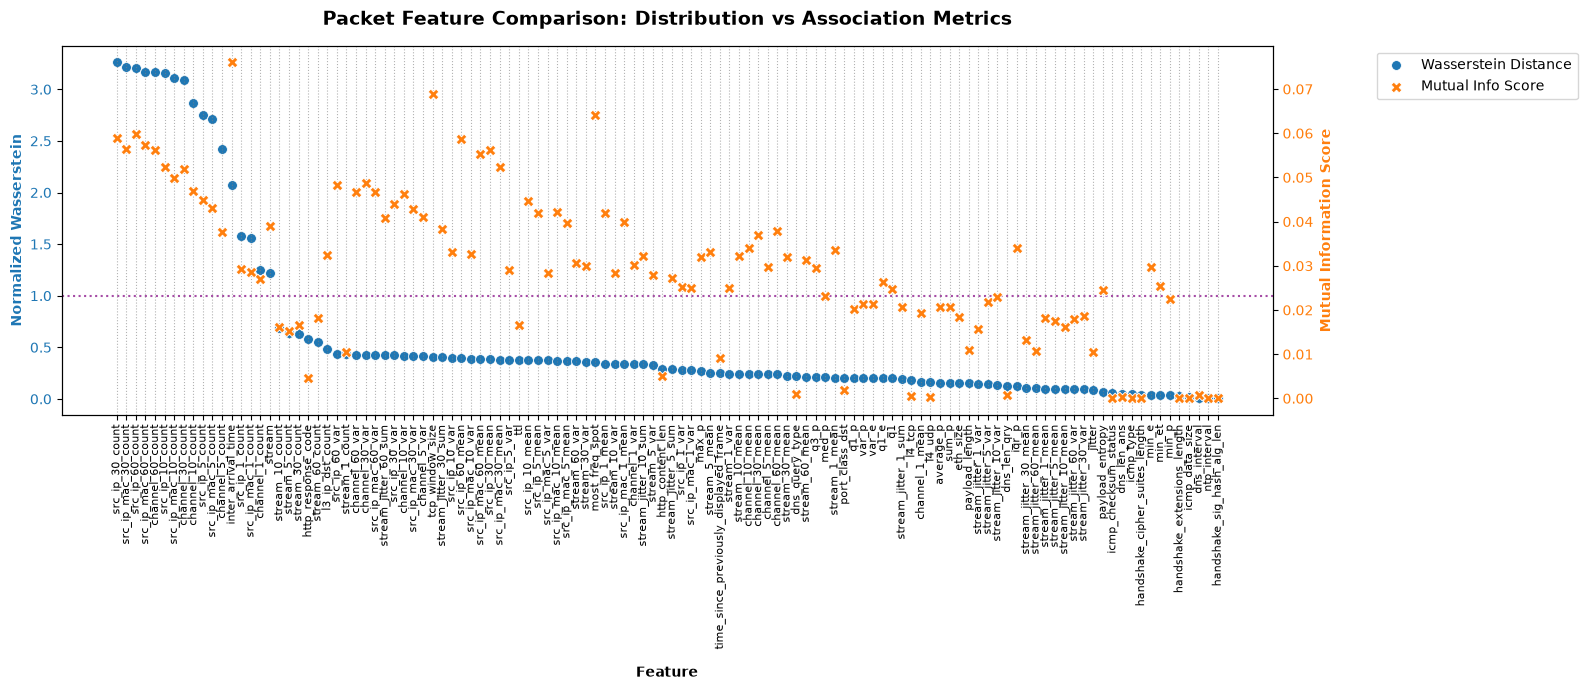

In [22]:
# 1. Cleanly merge and sort the two datasets
merged_df = wassData.merge(mutual_info_df, on='feature')
merged_df = merged_df.sort_values(by='normalized_wasserstein', ascending=False)

fig, ax1 = plt.subplots(figsize=(16, 7))

# 2. Plot Wasserstein on the Left Axis (ax1)
sns.scatterplot(
    data=merged_df, 
    x='feature', 
    y='normalized_wasserstein', 
    ax=ax1, 
    color='#1f77b4', 
    s=50,
    label='Wasserstein Distance',
    legend=False
)
ax1.set_ylabel('Normalized Wasserstein', color='#1f77b4', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xlabel('Feature', fontweight='bold', labelpad=12)

# FIX: Set the tick positions explicitly to ensure the grid registers perfectly
ax1.set_xticks(np.arange(len(merged_df)))
ax1.set_xticklabels(merged_df['feature'], rotation=90, fontsize=8)

# Re-apply threshold horizontal lines
ax1.axhline(y=wassThresh1, color="purple", linestyle=":", alpha=0.7)

# 3. Create Twin Axis for Mutual Information (ax2)
ax2 = ax1.twinx()

# 4. Plot Mutual Info on the Right Axis (ax2)
sns.scatterplot(
    data=merged_df, 
    x='feature', 
    y='mutual_info', 
    ax=ax2, 
    color='#ff7f0e', 
    marker='X', 
    s=60, 
    label='Mutual Info Score',
    legend=False
)
ax2.set_ylabel('Mutual Information Score', color='#ff7f0e', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# 5. Fix the Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, 
    labels1 + labels2, 
    loc='upper left', 
    bbox_to_anchor=(1.08, 1.0)
)

# 6. FIX: Force the grid onto ax1 and push its visual stack order (zorder) to the front
ax1.set_axisbelow(False)  # Pulls the grid lines in front of the background
ax1.grid(True, axis='x', linestyle=':', alpha=0.6, color='gray', zorder=10)

plt.title('Packet Feature Comparison: Distribution vs Association Metrics', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
starting_features = len(allPacketData['benign'].columns)
features_analyzed = len(ano_results['features_used'])
above = merged_df.loc[merged_df['normalized_wasserstein'] >= wassThresh1]
mean_mi_above = above['mutual_info'].mean()
below = merged_df.loc[merged_df['normalized_wasserstein'] < wassThresh1]
mean_mi_below = below['mutual_info'].mean()
print(f"Starting features: {starting_features}.\nFeatures Analyzed: {features_analyzed}.\n")
print(f"Number of Features above threshold: {len(above)}")
print(f"Mean mutual info above threshold: {mean_mi_above}")
print(f"Number of Features below threshold: {len(below)}")
print(f"Mean mutual info below threshold: {mean_mi_below}")

Starting features: 135.
Features Analyzed: 116.

Number of Features above threshold: 17
Mean mutual info above threshold: 0.047956028473493235
Number of Features below threshold: 99
Mean mutual info below threshold: 0.025602542460587987


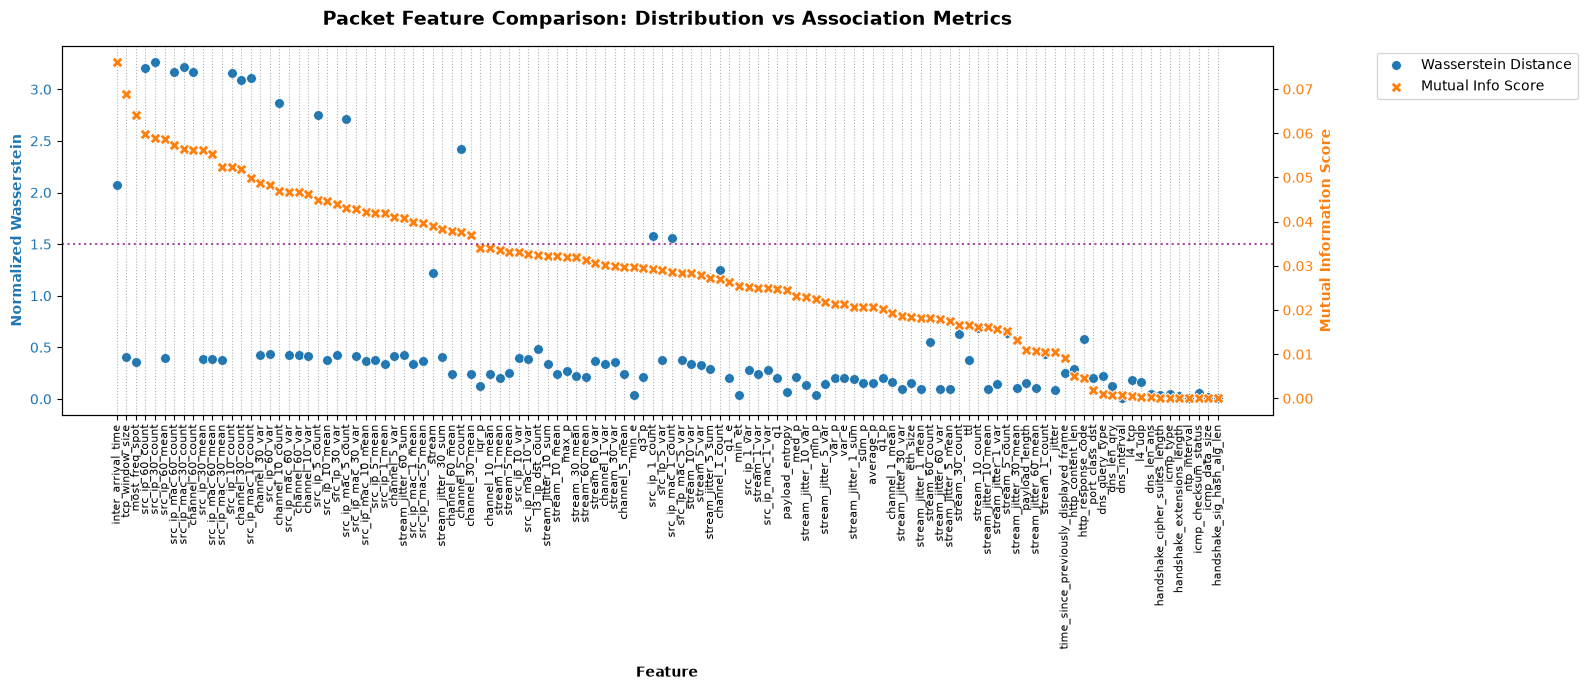

In [24]:
merged_df = merged_df.sort_values(by='mutual_info', ascending=False)
fig, ax1 = plt.subplots(figsize=(16, 7))

# 2. Plot Wasserstein on the Left Axis (ax1)
sns.scatterplot(
    data=merged_df, 
    x='feature', 
    y='normalized_wasserstein', 
    ax=ax1, 
    color='#1f77b4', 
    s=50,
    label='Wasserstein Distance',
    legend=False
)
ax1.set_ylabel('Normalized Wasserstein', color='#1f77b4', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xlabel('Feature', fontweight='bold', labelpad=12)

# FIX: Set the tick positions explicitly to ensure the grid registers perfectly
ax1.set_xticks(np.arange(len(merged_df)))
ax1.set_xticklabels(merged_df['feature'], rotation=90, fontsize=8)

# Re-apply threshold horizontal lines

# 3. Create Twin Axis for Mutual Information (ax2)
ax2 = ax1.twinx()
ax2.axhline(y=mutThress, color="purple", linestyle=":", alpha=0.7)

# 4. Plot Mutual Info on the Right Axis (ax2)
sns.scatterplot(
    data=merged_df, 
    x='feature', 
    y='mutual_info', 
    ax=ax2, 
    color='#ff7f0e', 
    marker='X', 
    s=60, 
    label='Mutual Info Score',
    legend=False
)
ax2.set_ylabel('Mutual Information Score', color='#ff7f0e', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# 5. Fix the Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, 
    labels1 + labels2, 
    loc='upper left', 
    bbox_to_anchor=(1.08, 1.0)
)

# 6. FIX: Force the grid onto ax1 and push its visual stack order (zorder) to the front
ax1.set_axisbelow(False)  # Pulls the grid lines in front of the background
ax1.grid(True, axis='x', linestyle=':', alpha=0.6, color='gray', zorder=10)

plt.title('Packet Feature Comparison: Distribution vs Association Metrics', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
starting_features = len(allPacketData['benign'].columns)
features_analyzed = len(ano_results['features_used'])
above = merged_df.loc[merged_df['mutual_info'] >= mutThress]
mean_mi_above = above['normalized_wasserstein'].mean()
below = merged_df.loc[merged_df['mutual_info'] < mutThress]
mean_mi_below = below['normalized_wasserstein'].mean()
print(f"Starting features: {starting_features}.\nFeatures Analyzed: {features_analyzed}.\n")
print(f"Number of Features above threshold: {len(above)}")
print(f"Mean Wasserstein above threshold: {mean_mi_above}")
print(f"Number of Features below threshold: {len(below)}")
print(f"Mean Wasserstein below threshold: {mean_mi_below}")

Starting features: 135.
Features Analyzed: 116.

Number of Features above threshold: 38
Mean Wasserstein above threshold: 1.278379982027184
Number of Features below threshold: 78
Mean Wasserstein below threshold: 0.2688819095646229


In [ ]:
final_ano_features = merged_df.loc[(merged_df['normalized_wasserstein'] > wassThresh1) | (merged_df['mutual_info'] > mutThress)]
print(len(final_ano_features))
final_ano_features

In [ ]:
final_ano_features.to_csv(results_dir / f"mack_final_ano_{len(final_ano_features)}features.csv")

41


## Classification

In [27]:
#These are the Unique ID's for flow data
flowNumericLables = ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Timestamp']

In [28]:
clf_results = run_flow_pipeline(dataDict=allFlowData,exclude_cols=flowNumericLables)

=== Step 1: structural profiling ===
[benign] 2 feature(s) have +/-inf values (mean/var computed excluding inf): {'Flow Bytes/s': 100, 'Flow Packets/s': 132}
[ddos] 2 feature(s) have +/-inf values (mean/var computed excluding inf): {'Flow Bytes/s': 10, 'Flow Packets/s': 1123}
[dos] 2 feature(s) have +/-inf values (mean/var computed excluding inf): {'Flow Bytes/s': 803, 'Flow Packets/s': 79521}
[dns] 2 feature(s) have +/-inf values (mean/var computed excluding inf): {'Flow Bytes/s': 13, 'Flow Packets/s': 61}
70 feature(s) with nonzero variance in at least one dataset
=== Step 4: statistical comparison (attack-vs-attack, attack-only sample) ===
[sample_attack_only_mix] sampled 200001 attack rows total across 5 class(es) (no benign)
=== Step 6: mutual information ranking (multiclass, attack-only sample) ===
[mutual_info:label_multiclass] Flow Bytes/s: dropped 7266/200001 rows (3.63%) due to inf/NaN
[mutual_info:label_multiclass] Flow Packets/s: dropped 7266/200001 rows (3.63%) due to inf/

In [29]:
clffpc = feature_profile_comparison(clf_results['profiles'])
clffpc.loc[clffpc['in_zero_var_cols']==True]

dtype  n_missing  pct_missing  n_inf  \
col_name            dataset                                            
Bwd PSH Flags       benign      int64          0          0.0      0   
                    bruteForce  int64          0          0.0      0   
                    ddos        int64          0          0.0      0   
                    dns         int64          0          0.0      0   
                    dos         int64          0          0.0      0   
                    xss         int64          0          0.0      0   
Bwd URG Flags       benign      int64          0          0.0      0   
                    bruteForce  int64          0          0.0      0   
                    ddos        int64          0          0.0      0   
                    dns         int64          0          0.0      0   
                    dos         int64          0          0.0      0   
                    xss         int64          0          0.0      0   
CWR Flag Count      bruteForce  int64          0          0.0      0   
ECE Flag Count      bruteForce  int64          0          0.0      0   
Fwd Bulk Rate Avg   benign      int64          0          0.0      0   
                    bruteForce  int64          0          0.0      0   
                    ddos        int64          0          0.0      0   
                    dns         int64          0          0.0      0   
                    dos         int64          0          0.0      0   
                    xss         int64          0          0.0      0   
Fwd Bytes/Bulk Avg  benign      int64          0          0.0      0   
                    bruteForce  int64          0          0.0      0   
                    ddos        int64          0          0.0      0   
                    dns         int64          0          0.0      0   
                    dos         int64          0          0.0      0   
                    xss         int64          0          0.0      0   
Fwd Packet/Bulk Avg benign      int64          0          0.0      0   
                    bruteForce  int64          0          0.0      0   
                    ddos        int64          0          0.0      0   
                    dns         int64          0          0.0      0   
                    dos         int64          0          0.0      0   
                    xss         int64          0          0.0      0   
Fwd URG Flags       benign      int64          0          0.0      0   
                    bruteForce  int64          0          0.0      0   
                    ddos        int64          0          0.0      0   
                    dns         int64          0          0.0      0   
                    dos         int64          0          0.0      0   
                    xss         int64          0          0.0      0   
URG Flag Count      benign      int64          0          0.0      0   
                    bruteForce  int64          0          0.0      0   
                    ddos        int64          0          0.0      0   
                    dns         int64          0          0.0      0   
                    dos         int64          0          0.0      0   
                    xss         int64          0          0.0      0   

                                is_numeric  is_excluded  mean  var  n_unique  \
col_name            dataset                                                    
Bwd PSH Flags       benign            True        False   0.0  0.0       1.0   
                    bruteForce        True        False   0.0  0.0       1.0   
                    ddos              True        False   0.0  0.0       1.0   
                    dns               True        False   0.0  0.0       1.0   
                    dos               True        False   0.0  0.0       1.0   
                    xss               True        False   0.0  0.0       1.0   
Bwd URG Flags       benign            True        False   0.0  0.0       1.0   

In [30]:
clffpc.loc[clffpc['in_numeric_cols']==False]

dtype  n_missing  pct_missing  n_inf  is_numeric  \
col_name  dataset                                                        
Dst IP    benign        str          0          0.0      0       False   
          bruteForce    str          0          0.0      0       False   
          ddos          str          0          0.0      0       False   
          dns           str          0          0.0      0       False   
          dos           str          0          0.0      0       False   
          xss           str          0          0.0      0       False   
Dst Port  benign      int64          0          0.0      0        True   
          bruteForce  int64          0          0.0      0        True   
          ddos        int64          0          0.0      0        True   
          dns         int64          0          0.0      0        True   
          dos         int64          0          0.0      0        True   
          xss         int64          0          0.0      0        True   
Flow ID   benign        str          0          0.0      0       False   
          bruteForce    str          0          0.0      0       False   
          ddos          str          0          0.0      0       False   
          dns           str          0          0.0      0       False   
          dos           str          0          0.0      0       False   
          xss           str          0          0.0      0       False   
Label     benign        str          0          0.0      0       False   
          bruteForce    str          0          0.0      0       False   
          ddos          str          0          0.0      0       False   
          dns           str          0          0.0      0       False   
          dos           str          0          0.0      0       False   
          xss           str          0          0.0      0       False   
Src IP    benign        str          0          0.0      0       False   
          bruteForce    str          0          0.0      0       False   
          ddos          str          0          0.0      0       False   
          dns           str          0          0.0      0       False   
          dos           str          0          0.0      0       False   
          xss           str          0          0.0      0       False   
Src Port  benign      int64          0          0.0      0        True   
          bruteForce  int64          0          0.0      0        True   
          ddos        int64          0          0.0      0        True   
          dns         int64          0          0.0      0        True   
          dos         int64          0          0.0      0        True   
          xss         int64          0          0.0      0        True   
Timestamp benign        str          0          0.0      0       False   
          bruteForce    str          0          0.0      0       False   
          ddos          str          0          0.0      0       False   
          dns           str          0          0.0      0       False   
          dos           str          0          0.0      0       False   
          xss           str          0          0.0      0       False   

                      is_excluded  mean  var  n_unique is_discrete  \
col_name  dataset                                                    
Dst IP    benign             True   NaN  NaN       NaN        None   
          bruteForce         True   NaN  NaN       NaN        None   
          ddos               True   NaN  NaN       NaN        None   
          dns                True   NaN  NaN       NaN        None   
          dos                True   NaN  NaN       NaN        None   
          xss                True   NaN  NaN       NaN        None   
Dst Port  benign             True   NaN  NaN       NaN        None   
          bruteForce         True   NaN  NaN       NaN        None   
          ddos               True   NaN  NaN       NaN        Non

In [37]:
wassThresh1 = 0.4
mutThress = 0.12
wassData = clf_results['Wasserstein']

In [42]:
merged_df

,feature,wasserstein,pooled_std,normalized_wasserstein,mutual_info,n_rows_used
21,Flow IAT Min,1.515534e+06,5.003840e+06,0.302874,0.283929,200001
5,Flow Duration,1.167617e+07,1.871686e+07,0.623832,0.244545,200001
7,Flow IAT Max,6.254775e+06,1.052008e+07,0.594556,0.242692,200001
14,Flow IAT Mean,2.987534e+06,5.732358e+06,0.521170,0.242663,200001
44,Flow Packets/s,4.356151e+04,2.418758e+05,0.180099,0.239357,192735
...,...,...,...,...,...,...
60,Bwd Packet/Bulk Avg,2.872152e+00,4.909686e+01,0.058500,0.011457,200001
57,Subflow Bwd Packets,7.066904e-01,1.109428e+01,0.063699,0.010547,200001
38,Fwd PSH Flags,2.841798e-02,1.223675e-01,0.232235,0.006418,200001
50,ECE Flag Count,3.188817e-03,3.754501e-02,0.084933,0.000678,200001


In [32]:
mutual_info_df = clf_results['mutual_info']['multiclass']

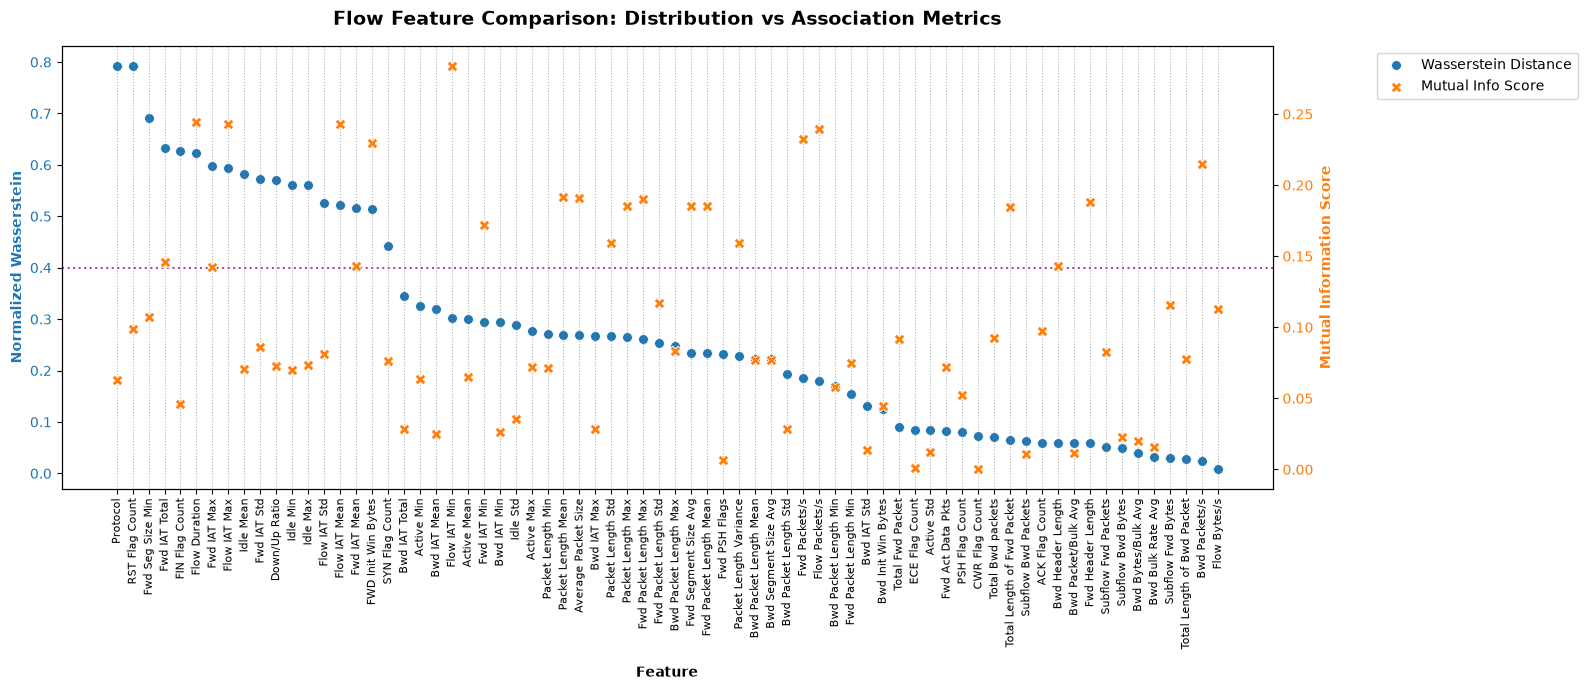

In [38]:
# 1. Cleanly merge and sort the two datasets
merged_df = wassData.merge(mutual_info_df, on='feature')
merged_df = merged_df.sort_values(by='normalized_wasserstein', ascending=False)

fig, ax1 = plt.subplots(figsize=(16, 7))

# 2. Plot Wasserstein on the Left Axis (ax1)
sns.scatterplot(
    data=merged_df, 
    x='feature', 
    y='normalized_wasserstein', 
    ax=ax1, 
    color='#1f77b4', 
    s=50,
    label='Wasserstein Distance',
    legend=False
)
ax1.set_ylabel('Normalized Wasserstein', color='#1f77b4', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xlabel('Feature', fontweight='bold', labelpad=12)

# FIX: Set the tick positions explicitly to ensure the grid registers perfectly
ax1.set_xticks(np.arange(len(merged_df)))
ax1.set_xticklabels(merged_df['feature'], rotation=90, fontsize=8)

# Re-apply threshold horizontal lines
ax1.axhline(y=wassThresh1, color="purple", linestyle=":", alpha=0.7)

# 3. Create Twin Axis for Mutual Information (ax2)
ax2 = ax1.twinx()

# 4. Plot Mutual Info on the Right Axis (ax2)
sns.scatterplot(
    data=merged_df, 
    x='feature', 
    y='mutual_info', 
    ax=ax2, 
    color='#ff7f0e', 
    marker='X', 
    s=60, 
    label='Mutual Info Score',
    legend=False
)
ax2.set_ylabel('Mutual Information Score', color='#ff7f0e', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# 5. Fix the Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, 
    labels1 + labels2, 
    loc='upper left', 
    bbox_to_anchor=(1.08, 1.0)
)

# 6. FIX: Force the grid onto ax1 and push its visual stack order (zorder) to the front
ax1.set_axisbelow(False)  # Pulls the grid lines in front of the background
ax1.grid(True, axis='x', linestyle=':', alpha=0.6, color='gray', zorder=10)

plt.title('Flow Feature Comparison: Distribution vs Association Metrics', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
starting_features = len(allFlowData['benign'].columns)
features_analyzed = len(clf_results['features_used'])
above = merged_df.loc[merged_df['normalized_wasserstein'] >= wassThresh1]
mean_mi_above = above['mutual_info'].mean()
below = merged_df.loc[merged_df['normalized_wasserstein'] < wassThresh1]
mean_mi_below = below['mutual_info'].mean()
print(f"Starting features: {starting_features}.\nFeatures Analyzed: {features_analyzed}.\n")
print(f"Number of Features above threshold: {len(above)}")
print(f"Mean mutual info above threshold: {mean_mi_above}")
print(f"Number of Features below threshold: {len(below)}")
print(f"Mean mutual info below threshold: {mean_mi_below}")

Starting features: 84.
Features Analyzed: 70.

Number of Features above threshold: 18
Mean mutual info above threshold: 0.12421175298339605
Number of Features below threshold: 52
Mean mutual info below threshold: 0.09597610394771385


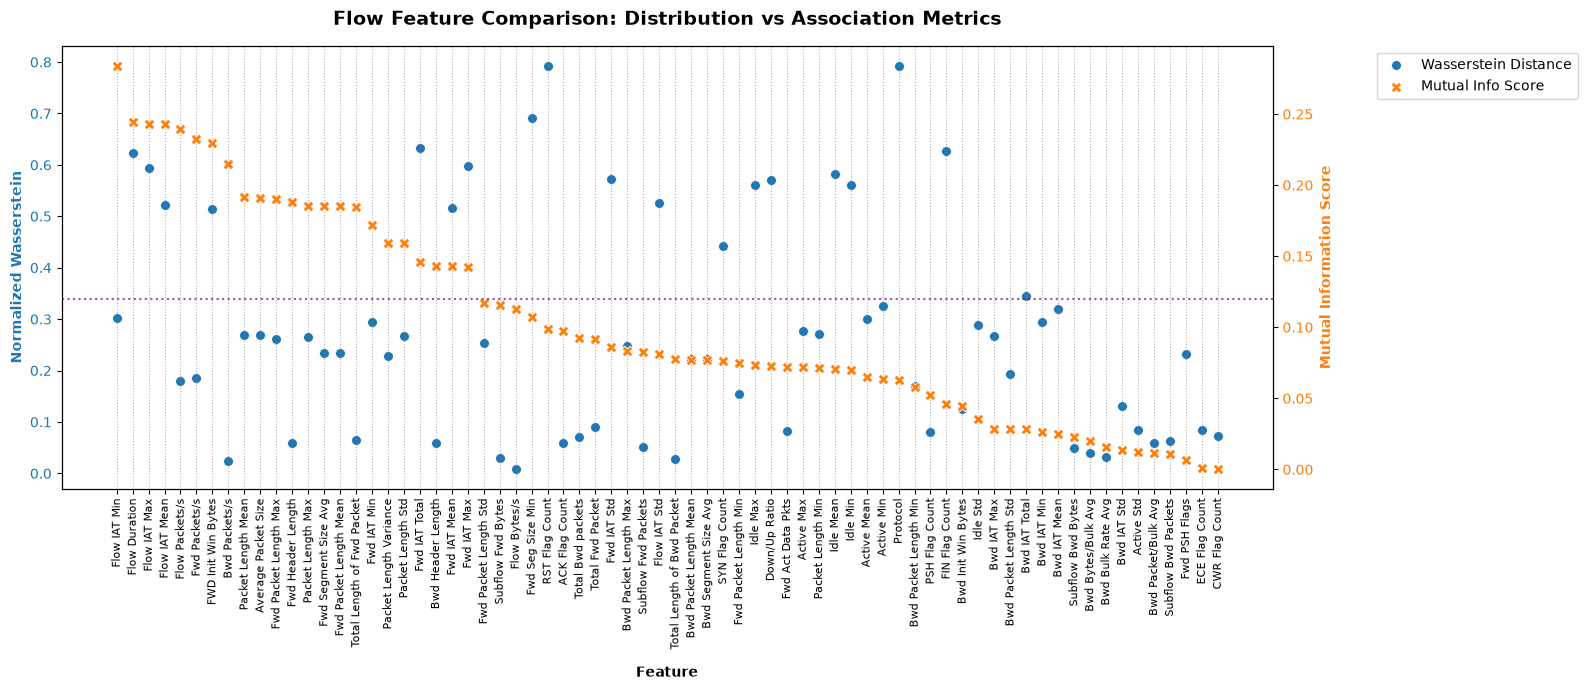

In [40]:
# 1. Cleanly merge and sort the two datasets
merged_df = wassData.merge(mutual_info_df, on='feature')
merged_df = merged_df.sort_values(by='mutual_info', ascending=False)

fig, ax1 = plt.subplots(figsize=(16, 7))

# 2. Plot Wasserstein on the Left Axis (ax1)
sns.scatterplot(
    data=merged_df, 
    x='feature', 
    y='normalized_wasserstein', 
    ax=ax1, 
    color='#1f77b4', 
    s=50,
    label='Wasserstein Distance',
    legend=False
)
ax1.set_ylabel('Normalized Wasserstein', color='#1f77b4', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xlabel('Feature', fontweight='bold', labelpad=12)

# FIX: Set the tick positions explicitly to ensure the grid registers perfectly
ax1.set_xticks(np.arange(len(merged_df)))
ax1.set_xticklabels(merged_df['feature'], rotation=90, fontsize=8)

# Re-apply threshold horizontal lines

# 3. Create Twin Axis for Mutual Information (ax2)
ax2 = ax1.twinx()
ax2.axhline(y=mutThress, color="purple", linestyle=":", alpha=0.7)

# 4. Plot Mutual Info on the Right Axis (ax2)
sns.scatterplot(
    data=merged_df, 
    x='feature', 
    y='mutual_info', 
    ax=ax2, 
    color='#ff7f0e', 
    marker='X', 
    s=60, 
    label='Mutual Info Score',
    legend=False
)
ax2.set_ylabel('Mutual Information Score', color='#ff7f0e', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# 5. Fix the Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, 
    labels1 + labels2, 
    loc='upper left', 
    bbox_to_anchor=(1.08, 1.0)
)

# 6. FIX: Force the grid onto ax1 and push its visual stack order (zorder) to the front
ax1.set_axisbelow(False)  # Pulls the grid lines in front of the background
ax1.grid(True, axis='x', linestyle=':', alpha=0.6, color='gray', zorder=10)

plt.title('Flow Feature Comparison: Distribution vs Association Metrics', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
starting_features = len(allFlowData['benign'].columns)
features_analyzed = len(clf_results['features_used'])
above = merged_df.loc[merged_df['mutual_info'] >= mutThress]
mean_mi_above = above['normalized_wasserstein'].mean()
below = merged_df.loc[merged_df['mutual_info'] < mutThress]
mean_mi_below = below['normalized_wasserstein'].mean()
print(f"Starting features: {starting_features}.\nFeatures Analyzed: {features_analyzed}.\n")
print(f"Number of Features above threshold: {len(above)}")
print(f"Mean Wasserstein above threshold: {mean_mi_above}")
print(f"Number of Features below threshold: {len(below)}")
print(f"Mean Wasserstein below threshold: {mean_mi_below}")

Starting features: 84.
Features Analyzed: 70.

Number of Features above threshold: 23
Mean Wasserstein above threshold: 0.3129412215229382
Number of Features below threshold: 47
Mean Wasserstein below threshold: 0.262659374586169


In [43]:
merged_df.head()

,feature,wasserstein,pooled_std,normalized_wasserstein,mutual_info,n_rows_used
21,Flow IAT Min,1.515534e+06,5.003840e+06,0.302874,0.283929,200001
5,Flow Duration,1.167617e+07,1.871686e+07,0.623832,0.244545,200001
7,Flow IAT Max,6.254775e+06,1.052008e+07,0.594556,0.242692,200001
14,Flow IAT Mean,2.987534e+06,5.732358e+06,0.521170,0.242663,200001
44,Flow Packets/s,4.356151e+04,2.418758e+05,0.180099,0.239357,192735


In [45]:
final_clf_features = merged_df.loc[(merged_df['normalized_wasserstein'] > wassThresh1) | (merged_df['mutual_info'] > mutThress)]

In [47]:
print(len(final_clf_features))
final_clf_features

34


,feature,wasserstein,pooled_std,normalized_wasserstein,mutual_info,n_rows_used
21,Flow IAT Min,1.515534e+06,5.003840e+06,0.302874,0.283929,200001
5,Flow Duration,1.167617e+07,1.871686e+07,0.623832,0.244545,200001
7,Flow IAT Max,6.254775e+06,1.052008e+07,0.594556,0.242692,200001
14,Flow IAT Mean,2.987534e+06,5.732358e+06,0.521170,0.242663,200001
44,Flow Packets/s,4.356151e+04,2.418758e+05,0.180099,0.239357,192735
43,Fwd Packets/s,4.413211e+04,2.371549e+05,0.186090,0.232179,200001
16,FWD Init Win Bytes,1.416563e+04,2.756163e+04,0.513962,0.229628,200001
68,Bwd Packets/s,2.140529e+02,8.869741e+03,0.024133,0.215105,200001
28,Packet Length Mean,6.412560e+01,2.380166e+02,0.269417,0.191791,200001
29,Average Packet Size,7.565789e+01,2.814301e+02,0.268834,0.191104,200001


In [ ]:
final_clf_features.to_csv(results_dir / f"mack_final_clf_{len(final_clf_features)}features.csv")